In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf                   



In [69]:
start = '2015-01-01'
end = '2025-12-31'
stock = 'GOOG'
data = yf.download(stock, start, end)   


[*********************100%***********************]  1 of 1 completed


In [70]:
data.reset_index(inplace=True)

In [71]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
1,2015-01-05,25.414501,25.931822,25.374442,25.878903,41196796
2,2015-01-06,24.825466,25.528499,24.780462,25.470387,57998800
3,2015-01-07,24.782932,25.086796,24.711219,25.074728,41301082
4,2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...,...
2760,2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2761,2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2762,2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900


In [72]:
ma_100_days = data.Close.rolling(100).mean()

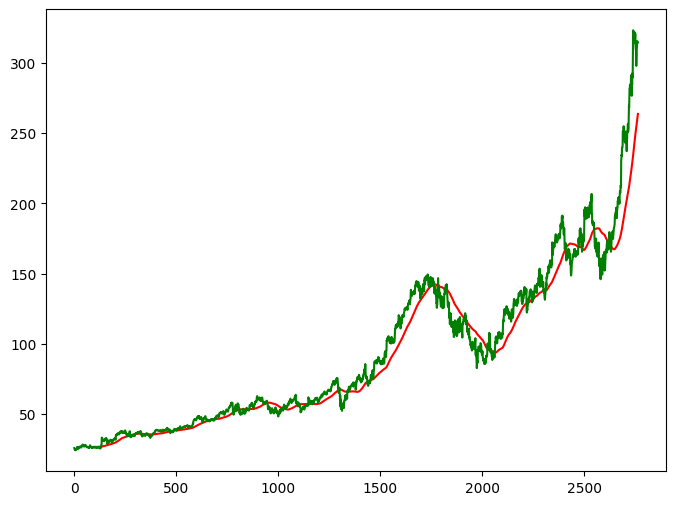

In [73]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [97]:
data.dropna(inplace=True)

In [98]:
data_train = pd.DataFrame(data.Close[0 : int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [99]:
data_train.shape[0]

2212

In [100]:
data_test.shape[0]

553

In [165]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [166]:
data_train_scale = scaler.fit_transform(data_train)

In [167]:
x = []
y = []

for i in range (100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [168]:
x, y = np.array(x), np.array(y)

In [ ]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [170]:
model = Sequential()
model.add(LSTM(units= 50, activation= 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units= 60, activation= 'relu', return_sequences= True))
model.add(Dropout(0.3))

model.add(LSTM(units= 80, activation= 'relu', return_sequences= True))
model.add(Dropout(0.4))

model.add(LSTM(units= 120, activation= 'relu',))
model.add(Dropout(0.5))

model.add(Dense(units = 1))




c:\Users\Noor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [171]:
model.compile(optimizer= 'adam', loss = 'mean_squared_error')

In [172]:
model.fit(x,y, epochs = 50, batch_size = 32, verbose= 1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - loss: 0.0384
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0086
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0070
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0072
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0068
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0064
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0060
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0048
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0053
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0054
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0056
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0059
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0049
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0047
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0051
Ep

In [173]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [174]:
pas_100_days = data_train.tail(100)

In [175]:
data_test = pd.concat([pas_100_days, data_test], ignore_index= True)

In [176]:
data_test_scale = scaler.fit_transform(data_test)

In [177]:
x = []
y = []

for i in range (100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

In [178]:
x, y = np.array(x), np.array(y)

In [179]:
y_predict = model.predict(x)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


In [180]:
scale = 1/scaler.scale_

In [181]:
y_predict = y_predict*scale

In [182]:
y = y*scale

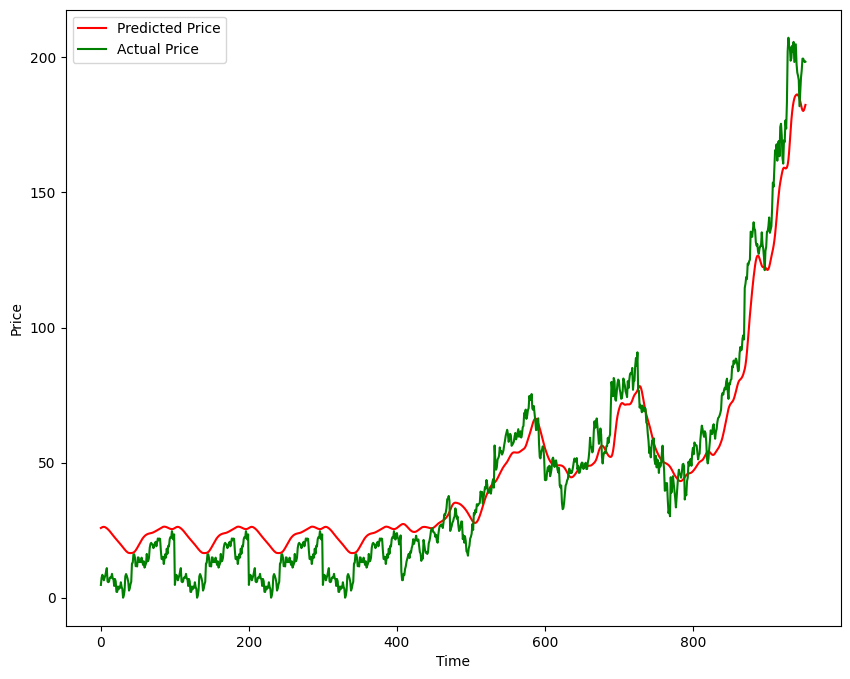

In [183]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Actual Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [184]:
model.save('Stock Prediction Model.keras')